In [1]:
from snc_sf.selection_function import SNCSelectionFunction
import matplotlib.pylab as plt
import os
import numpy as np
import polars as pl
%matplotlib inline
plt.style.use('%s/mystyle.mplstyle' % os.environ['MPL_STYLES'])


sncsf = SNCSelectionFunction('../../obs_100pc_dr19.csv')
sncsf.sample_posterior(1000)

In [2]:
MG_lum = np.linspace(2.5, 22.5, 75)

N_boot = np.zeros((MG_lum.shape[0] - 1, 1000))

MG = sncsf.data['phot_g_mean_mag'] + 5 * np.log10(1e-3 * sncsf.data['parallax']) + 5
filtered = sncsf.data.filter((pl.col("phot_g_mean_mag") < 20)  & (MG < 10 * sncsf.data['g_rp'] + 5))
MG = filtered.select(pl.col('phot_g_mean_mag') + 5 * np.log10(1e-3 * pl.col('parallax')) + 5).to_numpy().reshape((-1, ))

for i in range(1000):
    sub_boot = filtered.select(pl.col("pselect_samps").arr.get(i)).to_numpy().reshape((-1, ))
    Veff = filtered.select(pl.col("Veff_samps").arr.get(i)).to_numpy().reshape((-1, ))
    ev = np.isfinite(sub_boot) & np.isfinite(Veff)
    idx = np.random.choice(np.sum(ev), np.sum(ev))
    N_boot[:, i], _ = np.histogram(MG[ev][idx],
                                   weights=1 / (sub_boot[ev][idx] * Veff[ev][idx]), bins=MG_lum)


In [3]:
N, _ = np.histogram(MG,
                    bins=MG_lum, weights=np.zeros(len(MG)) + 1 / (4/3 * np.pi * 100 ** 3))




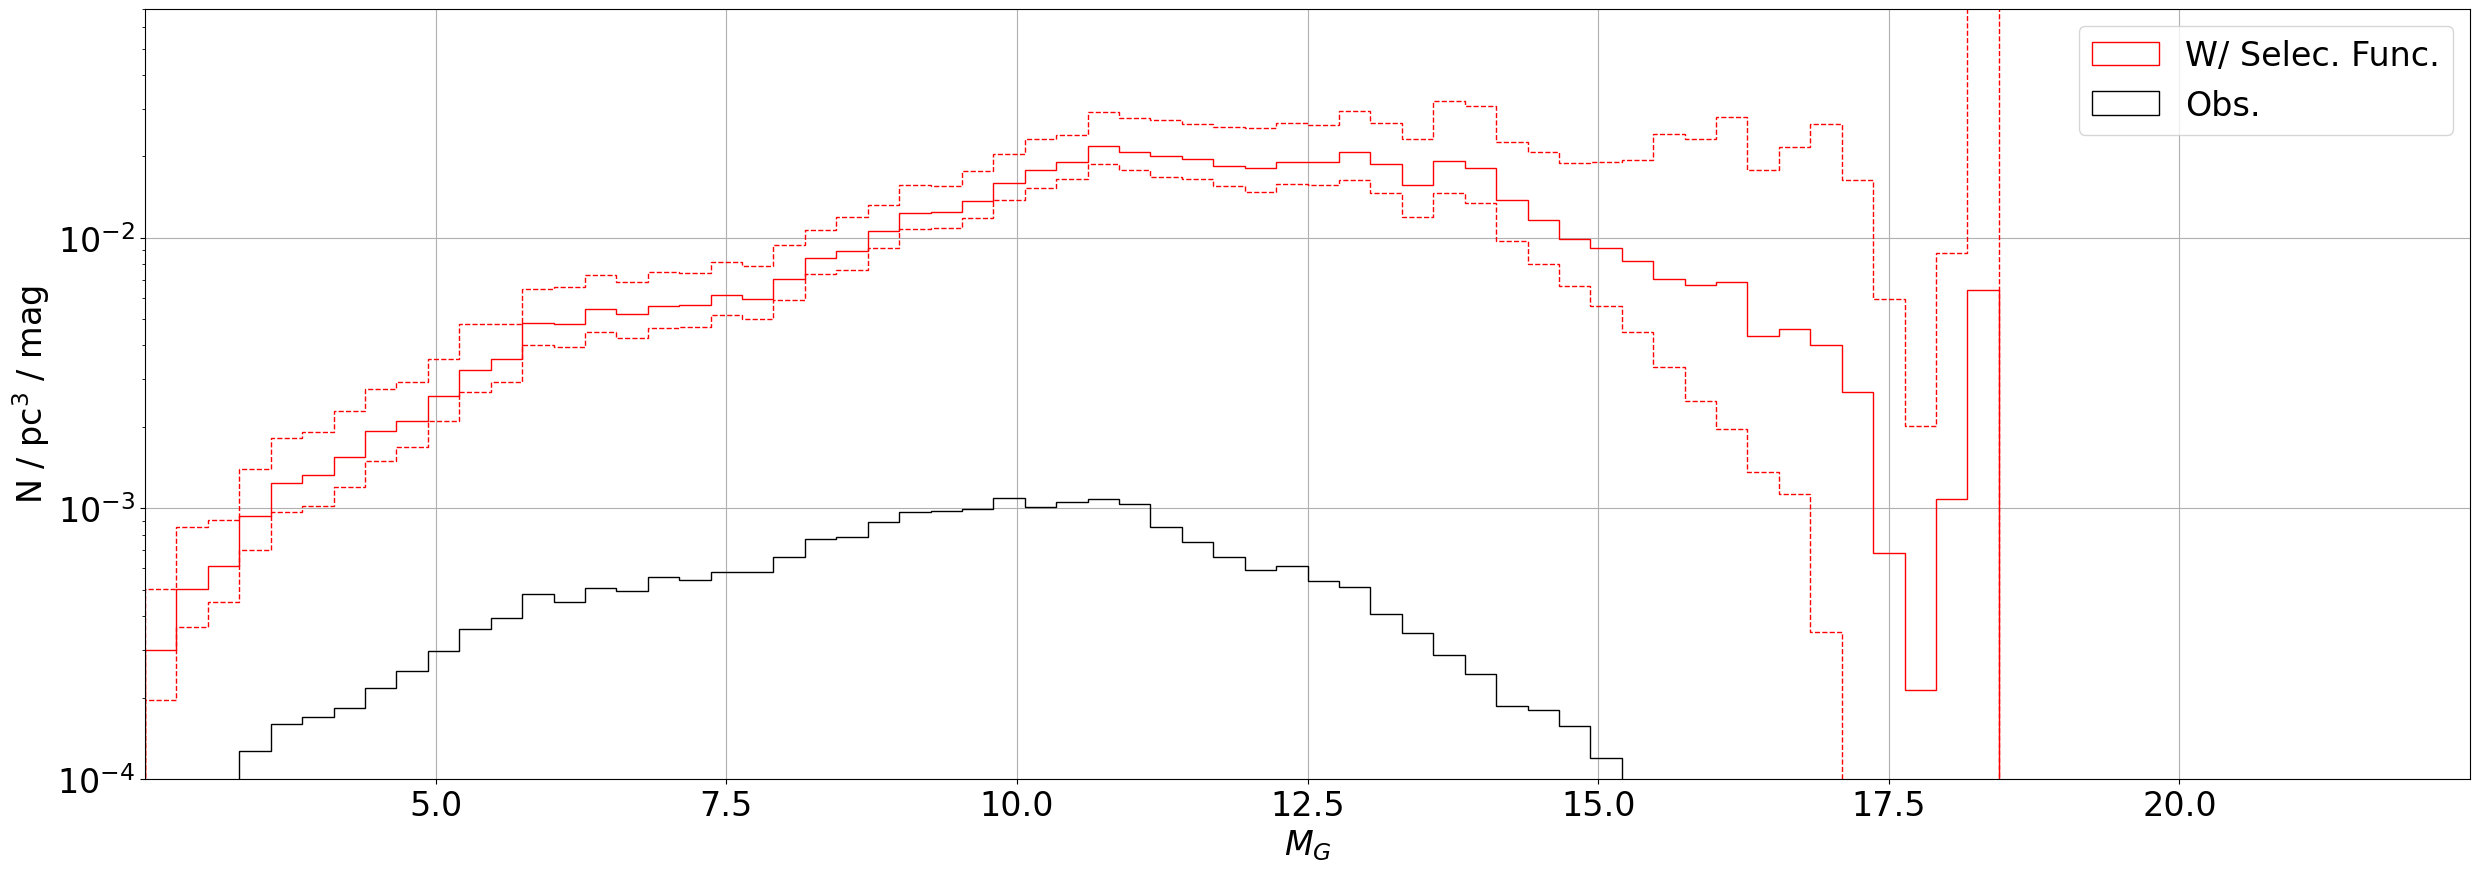

In [4]:
plt.figure(figsize=(30, 10))

plt.hist(MG_lum[:-1], bins=MG_lum, weights=np.nanmedian(N_boot, axis=1) / (MG_lum[1] - MG_lum[0]), label='W/ Selec. Func.',
        histtype='step', lw=2, edgecolor='r')
plt.hist(MG_lum[:-1], bins=MG_lum,
         weights=np.nanpercentile(N_boot, 2.5, axis=1) / (MG_lum[1] - MG_lum[0]),
         label=None,
        histtype='step', lw=1, linestyle='--', edgecolor='r')
plt.hist(MG_lum[:-1], bins=MG_lum,
         weights=np.nanpercentile(N_boot, 97.5, axis=1) / (MG_lum[1] - MG_lum[0]),
         label=None,
        histtype='step', lw=1, linestyle='--', edgecolor='r')

plt.hist(MG_lum[:-1], bins=MG_lum, weights=N / (MG_lum[1] - MG_lum[0]), label='Obs.',
        histtype='step', lw=2, edgecolor='k')

plt.xticks(np.arange(5, 22.5, 2.5))

plt.grid()
plt.xlim((2.5, 22.5))
plt.ylim((1e-4, 7e-2))
plt.yscale('log')
plt.xlabel(r'$M_G$')
plt.ylabel(r'N / pc$^3$ / mag')
plt.legend()
plt.show()




In [5]:
MG_cuts = [[2.51, 4.325],
           [4.325, 5.553],
           [5.553, 8.10 ],
           [8.10, 16.60]]

truth = np.array([[0.0024, 0.0003],
                     [0.0033, 0.0004],
                     [0.0135, 0.0025],
                     [0.0917, 0.0132]])


labels = ['F Dwarfs', 'G Dwarfs', 'K Dwarfs', 'M Dwarfs']

num_dens_all = np.zeros((len(MG_cuts), 3))

for it in range(len(MG_cuts)):
    nits = 1000    
    num_dens = np.zeros(nits)

    
    MG = sncsf.data['phot_g_mean_mag'] + 5 * np.log10(1e-3 * sncsf.data['parallax']) + 5

    filtered = sncsf.data.filter((pl.col("phot_g_mean_mag") < 20) &\
                                 (MG > MG_cuts[it][0]) & (MG < MG_cuts[it][1]) & (MG < 10 * sncsf.data['g_rp'] + 5))
    
    for i in range(1000):
        sub_boot = filtered.select(pl.col("pselect_samps").arr.get(i)).to_numpy().reshape((-1, ))
        Veff = filtered.select(pl.col("Veff_samps").arr.get(i)).to_numpy().reshape((-1, ))
        ev = np.isfinite(sub_boot) & np.isfinite(Veff)
        idx = np.random.choice(np.sum(ev), np.sum(ev))
        num_dens[i] = np.nansum(1 / (sub_boot[ev][idx] * Veff[ev][idx]))
    num_dens_all[it] = np.nanpercentile(num_dens, [2.5, 50, 97.5])




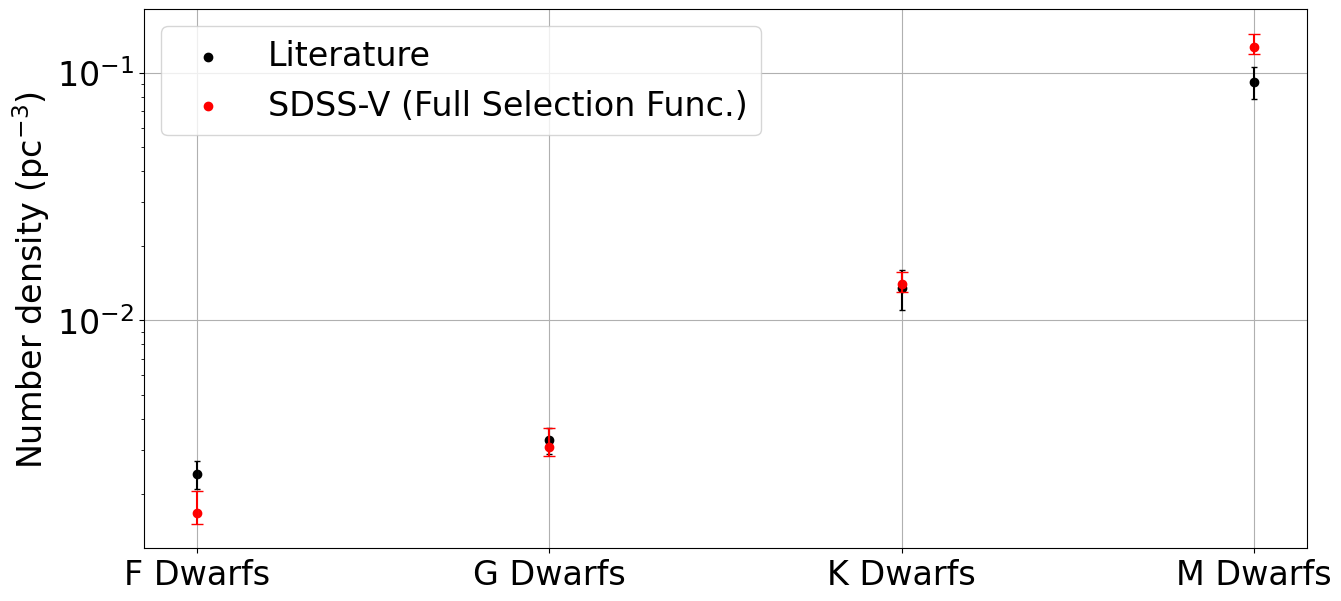

In [6]:
plt.figure(figsize=(15, 7))
plt.scatter(np.arange(len(MG_cuts)), truth[:, 0], c='k', label='Literature')
plt.errorbar(np.arange(len(MG_cuts)), truth[:, 0], yerr=truth[:, 1],
             fmt='none', ecolor='k')

plt.scatter(np.arange(len(MG_cuts)), num_dens_all[:, 1], c='r', label='SDSS-V (Full Selection Func.)')
plt.errorbar(np.arange(len(MG_cuts)), num_dens_all[:, 1], yerr=np.diff(num_dens_all).T,
             fmt='none', ecolor='r', capsize=4)

plt.grid()
plt.yscale('log')
plt.ylabel(r'Number density (pc$^{-3}$)')
plt.legend()
# plt.ylim(1e-3, 1e0)
plt.xticks(np.arange(len(MG_cuts)), labels)
plt.show()


